In [1]:
# pip install pandas requests plotly

import time
import re
import requests
import pandas as pd
from typing import Optional, Literal, List
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Market = Literal["spot", "usdm_futures", "coinm_futures"]

VALID_INTERVALS = {
    "1m","3m","5m","15m","30m",
    "1h","2h","4h","6h","8h","12h",
    "1d","3d","1w","1M"
}

BASES = {
    "spot": ("https://data-api.binance.vision", "/api/v3/klines", 1000),
    "usdm_futures": ("https://fapi.binance.com", "/fapi/v1/klines", 1500),
    "coinm_futures": ("https://dapi.binance.com", "/dapi/v1/klines", 1500),
}

def _to_ms(dt: str) -> int:
    ts = pd.to_datetime(dt, utc=True)
    return int(ts.value // 1_000_000)  # ns -> ms

def fetch_binance_klines(
    symbol: str,
    interval: str,
    start: str,
    end: Optional[str] = None,       # None -> fetch to latest
    market: Market = "spot",
    pause_s: float = 0.15,
    verbose: bool = False,
) -> pd.DataFrame:
    symbol = symbol.upper().strip()
    if interval not in VALID_INTERVALS:
        raise ValueError(f"Invalid interval '{interval}'. Use one of: {sorted(VALID_INTERVALS)}")

    base, path, limit = BASES[market]
    start_ms = _to_ms(start)
    end_ms = _to_ms(end) if end else None

    rows = []
    req = 0

    if verbose:
        print(f"[START] {market=} {symbol=} {interval=} {start=} {end=} {limit=}")

    while True:
        req += 1
        params = {"symbol": symbol, "interval": interval, "startTime": start_ms, "limit": limit}
        if end_ms is not None:
            params["endTime"] = end_ms

        if verbose:
            sdt = pd.to_datetime(start_ms, unit="ms", utc=True)
            edt = pd.to_datetime(end_ms, unit="ms", utc=True) if end_ms else "LATEST"
            print(f"[REQ {req:03d}] start={sdt} end={edt} ...", end="")

        r = requests.get(base + path, params=params, timeout=30)
        if r.status_code != 200:
            if verbose:
                print(f" -> ERROR {r.status_code}: {r.text[:200]}")
            r.raise_for_status()

        data = r.json()
        if not data:
            if verbose:
                print(" -> 0 rows (done)")
            break

        rows.extend(data)

        last_open = data[-1][0]
        returned = len(data)

        if verbose:
            first_open = pd.to_datetime(data[0][0], unit="ms", utc=True)
            last_open_dt = pd.to_datetime(last_open, unit="ms", utc=True)
            print(f" -> {returned} rows ({first_open} .. {last_open_dt})")

        start_ms = last_open + 1

        if returned < limit:
            if verbose:
                print("[STOP] returned < limit (no more pages)")
            break

        if end_ms is not None and start_ms >= end_ms:
            if verbose:
                print("[STOP] reached end")
            break

        time.sleep(pause_s)

    cols = [
        "open_time_ms","open","high","low","close","volume",
        "close_time_ms","quote_volume","num_trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ]
    df = pd.DataFrame(rows, columns=cols)
    if df.empty:
        return df

    # numeric conversions
    for c in ["open","high","low","close","volume","quote_volume","taker_buy_base","taker_buy_quote","num_trades"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df["open_time"] = pd.to_datetime(df["open_time_ms"], unit="ms", utc=True)
    df = df.sort_values("open_time").reset_index(drop=True)

    return df[[
        "open_time","open","high","low","close","volume",
        "quote_volume","num_trades","taker_buy_base","taker_buy_quote"
    ]]

def _parse_show_last(show_last: str) -> pd.Timedelta:
    s = show_last.strip()
    # Friendly words
    if re.search(r"week(s)?$", s):
        n = int("".join(ch for ch in s if ch.isdigit()) or "1")
        return pd.Timedelta(days=7*n)
    if re.search(r"month(s)?$", s) or s.endswith("M"):
        n = int("".join(ch for ch in s if ch.isdigit()) or "1")
        return pd.Timedelta(days=30*n)
    if s.endswith("w"):
        n = int(s[:-1])
        return pd.Timedelta(days=7*n)
    # Timedelta parses "30m","2h","1d"
    return pd.Timedelta(s)

def plot_interactive(
    df: pd.DataFrame,
    symbol: str,
    interval: str,
    market: Market = "spot",
    tz: str = "Asia/Karachi",
    ma_windows: Optional[List[int]] = None,  # e.g. [20,50,100]
    show_last: Optional[str] = None,         # e.g. "2h","1d","1w","1M","30m"
):
    if df.empty:
        raise ValueError("No data to plot.")

    ma_windows = ma_windows or []

    # Work on full data first for proper MA calculation
    full = df.copy()
    full["t"] = full["open_time"].dt.tz_convert(tz)

    for w in ma_windows:
        full[f"MA{w}"] = full["close"].rolling(window=w, min_periods=w).mean()

    # Slice for display only
    plot_df = full
    if show_last:
        window = _parse_show_last(show_last)
        tmax = plot_df["t"].max()
        plot_df = plot_df[plot_df["t"] >= (tmax - window)]

    # Build interactive chart (candles + volume)
    fig = make_subplots(
        rows=2, cols=1, shared_xaxes=True,
        row_heights=[0.72, 0.28],
        vertical_spacing=0.06,
        specs=[[{"secondary_y": False}], [{"secondary_y": False}]]
    )

    # Candlesticks with rich hover
    fig.add_trace(
        go.Candlestick(
            x=plot_df["t"],
            open=plot_df["open"],
            high=plot_df["high"],
            low=plot_df["low"],
            close=plot_df["close"],
            name="OHLC",
            customdata=plot_df[["volume","quote_volume","num_trades"]].to_numpy(),
            hovertemplate=(
                "<b>%{x}</b><br>"
                "Open: %{open}<br>"
                "High: %{high}<br>"
                "Low: %{low}<br>"
                "Close: %{close}<br>"
                "Volume: %{customdata[0]:,.4f}<br>"
                "Quote Vol: %{customdata[1]:,.2f}<br>"
                "Trades: %{customdata[2]:,.0f}<br>"
                "<extra></extra>"
            ),
        ),
        row=1, col=1
    )

    # MA lines
    for w in ma_windows:
        col = f"MA{w}"
        fig.add_trace(
            go.Scatter(
                x=plot_df["t"],
                y=plot_df[col],
                mode="lines",
                name=col,
                hovertemplate=f"<b>%{{x}}</b><br>{col}: %{{y:.2f}}<extra></extra>",
            ),
            row=1, col=1
        )

    # Volume bars
    fig.add_trace(
        go.Bar(
            x=plot_df["t"],
            y=plot_df["volume"],
            name="Volume",
            hovertemplate="<b>%{x}</b><br>Volume: %{y:,.4f}<extra></extra>",
        ),
        row=2, col=1
    )

    fig.update_layout(
        title=f"{symbol.upper()} ({market}) — {interval}",
        xaxis_rangeslider_visible=False,
        hovermode="x unified",
        margin=dict(l=40, r=25, t=60, b=40),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    )
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Volume", row=2, col=1)

    fig.show()




[START] market='spot' symbol='BTCUSDT' interval='5m' start='2026-03-01' end=None limit=1000
[REQ 001] start=2026-03-01 00:00:00+00:00 end=LATEST ... -> 970 rows (2026-03-01 00:00:00+00:00 .. 2026-03-04 08:45:00+00:00)
[STOP] returned < limit (no more pages)


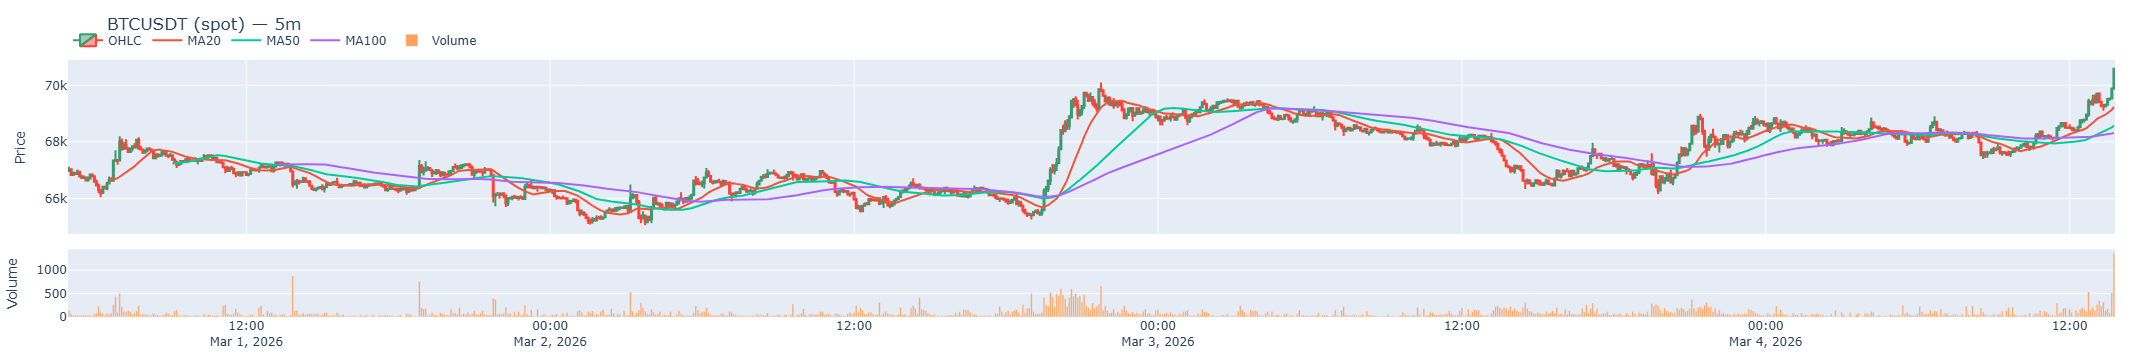

In [4]:
symbol = "BTCUSDT"
interval = "5m"
start = "2026-03-01"
end = None              # fetch till latest
market = "spot"

df = fetch_binance_klines(symbol, interval, start, end=end, market=market, verbose=True)
plot_interactive(
    df,
    symbol=symbol,
    interval=interval,
    market=market,
    ma_windows=[20, 50, 100],
    show_last=""       # only display last 2 hours
)

In [ ]:
symbol = "BTCUSDT"
interval = "5m"                 # valid intervals only
start = "2026-03-01"
end = None                      # None -> fetch till latest
market = "spot"

df = fetch_binance_klines(symbol, interval, start, end=end, market=market, verbose=True)
plot_close_with_mas(
    df,
    symbol=symbol,
    interval=interval,
    market=market,
    ma_windows=[5, 10, 20],
    show_last="1h"              # plot only last 1 week (try "1d", "1h", "30m", "1M")
)

In [ ]:
symbol = "BTCUSDT"
interval = "15m"                 # valid intervals only
start = "2026-02-01"
end = None                      # None -> fetch till latest
market = "spot"

df = fetch_binance_klines(symbol, interval, start, end=end, market=market, verbose=True)
plot_close_with_mas(
    df,
    symbol=symbol,
    interval=interval,
    market=market,
    ma_windows=[20, 50, 100],
    show_last="1d"              # plot only last 1 week (try "1d", "1h", "30m", "1M")
)